# 02 — Préparation des données

Ce notebook remplace les deux anciens notebooks `02_processing_train` / `02_processing_test`.
Toute la préparation vit désormais dans **un seul pipeline scikit-learn** (`src/features.py`), **appris sur le train uniquement**
puis appliqué tel quel au test. Il corrige trois défauts de la version précédente :

| Problème (v1) | Conséquence | Correction (v2) |
|---|---|---|
| `log1p` appliqué deux fois sur `SalePrice` | scores et soumission faux (prix ≈ 11.7 $) | `log1p` à un seul endroit (`src/data.py`) |
| Un `OneHotEncoder` refit sur le test | 99 % des maisons du test encodées « chauffage au sol » | encodeur appris sur le train, `handle_unknown` |
| NA imputés par le mode | 690 maisons sans cheminée notées « Gd » | NA = « absence » → `None` / 0 |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_test, load_train, remove_outliers
from src.features import HouseFeatureEngineer, build_preprocessor
from src.config import TRAIN_PATH
from src import visualization as viz  # palette et style partagés

pd.set_option("display.max_columns", 30)

## 1. Chargement, outliers et cible

Les deux maisons de plus de 4 000 sq ft vendues à bas prix sont signalées par l'auteur du dataset (De Cock, 2011). Elles sont retirées **du train uniquement** : chaque maison du test doit recevoir un prix.

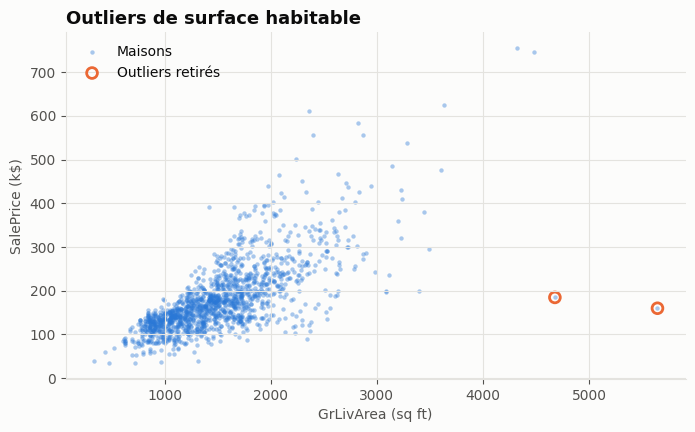

Train : (1458, 79)  |  Test : (1459, 79)  |  outliers retirés : 2
Cible log1p(SalePrice) : min 10.46  max 13.53  (une seule transformation)


In [2]:
raw = pd.read_csv(TRAIN_PATH)
outliers = raw[(raw.GrLivArea > 4000) & (raw.SalePrice < 300_000)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(raw.GrLivArea, raw.SalePrice / 1e3, s=10, color=viz.ACCENT, alpha=0.4, linewidths=0, label="Maisons")
ax.scatter(outliers.GrLivArea, outliers.SalePrice / 1e3, s=60, facecolors="none", edgecolors=viz.SECONDARY,
           linewidths=2, label="Outliers retirés")
ax.set(xlabel="GrLivArea (sq ft)", ylabel="SalePrice (k$)", title="Outliers de surface habitable")
ax.legend(frameon=False)
plt.show()

X, y = load_train()
X_test, test_ids = load_test()
print(f"Train : {X.shape}  |  Test : {X_test.shape}  |  outliers retirés : {len(raw) - len(X)}")
print(f"Cible log1p(SalePrice) : min {y.min():.2f}  max {y.max():.2f}  (une seule transformation)")

## 2. Valeurs manquantes : « NA » veut souvent dire « absent »

D'après `data_description.txt`, un NA dans `FireplaceQu`, `GarageType`, `BsmtQual`… signifie que la maison **n'a pas** l'équipement. On les remplace par `None` (catégorielles) ou 0 (surfaces), et les qualités deviennent des échelles ordinales (`Po`=1 … `Ex`=5).

In [3]:
engineer = HouseFeatureEngineer().fit(X)
engineered = engineer.transform(X)

no_fireplace = X.FireplaceQu.isna()
v1 = X.FireplaceQu.fillna(X.FireplaceQu.mode()[0])[no_fireplace].value_counts()
v2 = engineered.loc[no_fireplace, "FireplaceQu"].map({0.0: "None (0)"}).value_counts()
comparison = pd.concat({"v1 : imputation par le mode": v1, "v2 : absence (ordinal 0)": v2}, axis=1)
comparison = comparison.fillna(0).astype(int)
print(f"{no_fireplace.sum()} maisons sans cheminée :")
comparison

690 maisons sans cheminée :


,v1 : imputation par le mode,v2 : absence (ordinal 0)
FireplaceQu,,
Gd,690,0
None (0),0,690


In [4]:
remaining = engineered.isna().sum()
print("NA restants après feature engineering (imputés ensuite par médiane/mode appris sur le train) :")
remaining[remaining > 0]

NA restants après feature engineering (imputés ensuite par médiane/mode appris sur le train) :


Electrical    1
dtype: int64

## 3. Nouvelles variables

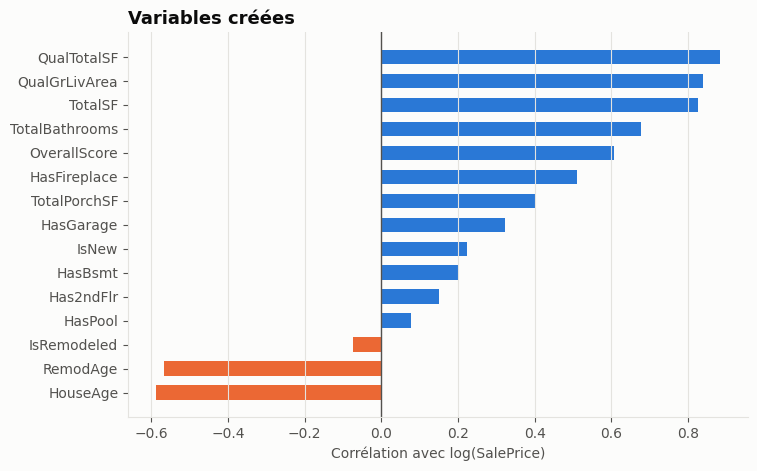

In [5]:
new_features = ["TotalSF", "QualTotalSF", "QualGrLivArea", "TotalBathrooms", "HouseAge", "RemodAge",
                "TotalPorchSF", "OverallScore", "HasGarage", "HasBsmt", "Has2ndFlr", "HasFireplace",
                "IsRemodeled", "IsNew", "HasPool"]
corr = engineered[new_features].corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(corr.index, corr.values, color=np.where(corr.values > 0, viz.ACCENT, viz.SECONDARY), height=0.6)
ax.axvline(0, color=viz.TEXT_MUTED, linewidth=1)
ax.grid(axis="y", visible=False)
ax.set(xlabel="Corrélation avec log(SalePrice)", title="Variables créées")
plt.show()

## 4. Pipeline complet : train et test ont exactement les mêmes colonnes

In [6]:
prep = build_preprocessor("linear").fit(X)
Xt, Xt_test = prep.transform(X), prep.transform(X_test)
names = prep.named_steps["columns"].get_feature_names_out()

print(f"Colonnes train : {Xt.shape[1]}  |  colonnes test : {Xt_test.shape[1]}")
print(f"NaN train : {np.isnan(Xt).sum()}  |  NaN test : {np.isnan(Xt_test).sum()}")

Colonnes train : 257  |  colonnes test : 257
NaN train : 0  |  NaN test : 0


In [7]:
# Vérification du bug v1 : part des maisons du test encodées avec un chauffage GasA
tree_prep = build_preprocessor("tree").fit(X)
encoded_test = pd.DataFrame(tree_prep.transform(X_test), columns=tree_prep.named_steps["columns"].get_feature_names_out())
print(f"Test — Heating = GasA dans les données brutes : {(X_test.Heating == 'GasA').mean():.1%}")
print(f"Test — Heating_GasA = 1 après encodage v2      : {encoded_test['Heating_GasA'].mean():.1%}")
print("(v1 : colonne absente du test → remplie de 0 → 0.0 %)")

Test — Heating = GasA dans les données brutes : 99.1%
Test — Heating_GasA = 1 après encodage v2      : 99.1%
(v1 : colonne absente du test → remplie de 0 → 0.0 %)


## Conclusion

- Une seule transformation `log1p` de la cible, des outliers retirés du train seulement.
- Les NA « absence » ne sont plus confondus avec des valeurs inconnues ; 15 variables métier ajoutées.
- Le pipeline est appris sur le train et réutilisé sur le test : colonnes identiques, aucun NaN, encodage cohérent.
- Ce même pipeline est intégré dans chaque modèle (`src/models.py`) : pendant la cross-validation il est **réappris sur chaque fold**, ce qui supprime toute fuite de données.

➡️ Suite : `03_modeling.ipynb`.